data_slip.shape=(869, 290)
time_slip.shape=(869,)
data_no_slip.shape=(149, 290)
time_no_slip.shape=(149,)
data_non_contact.shape=(839, 290)
time_non_contact.shape=(839,)


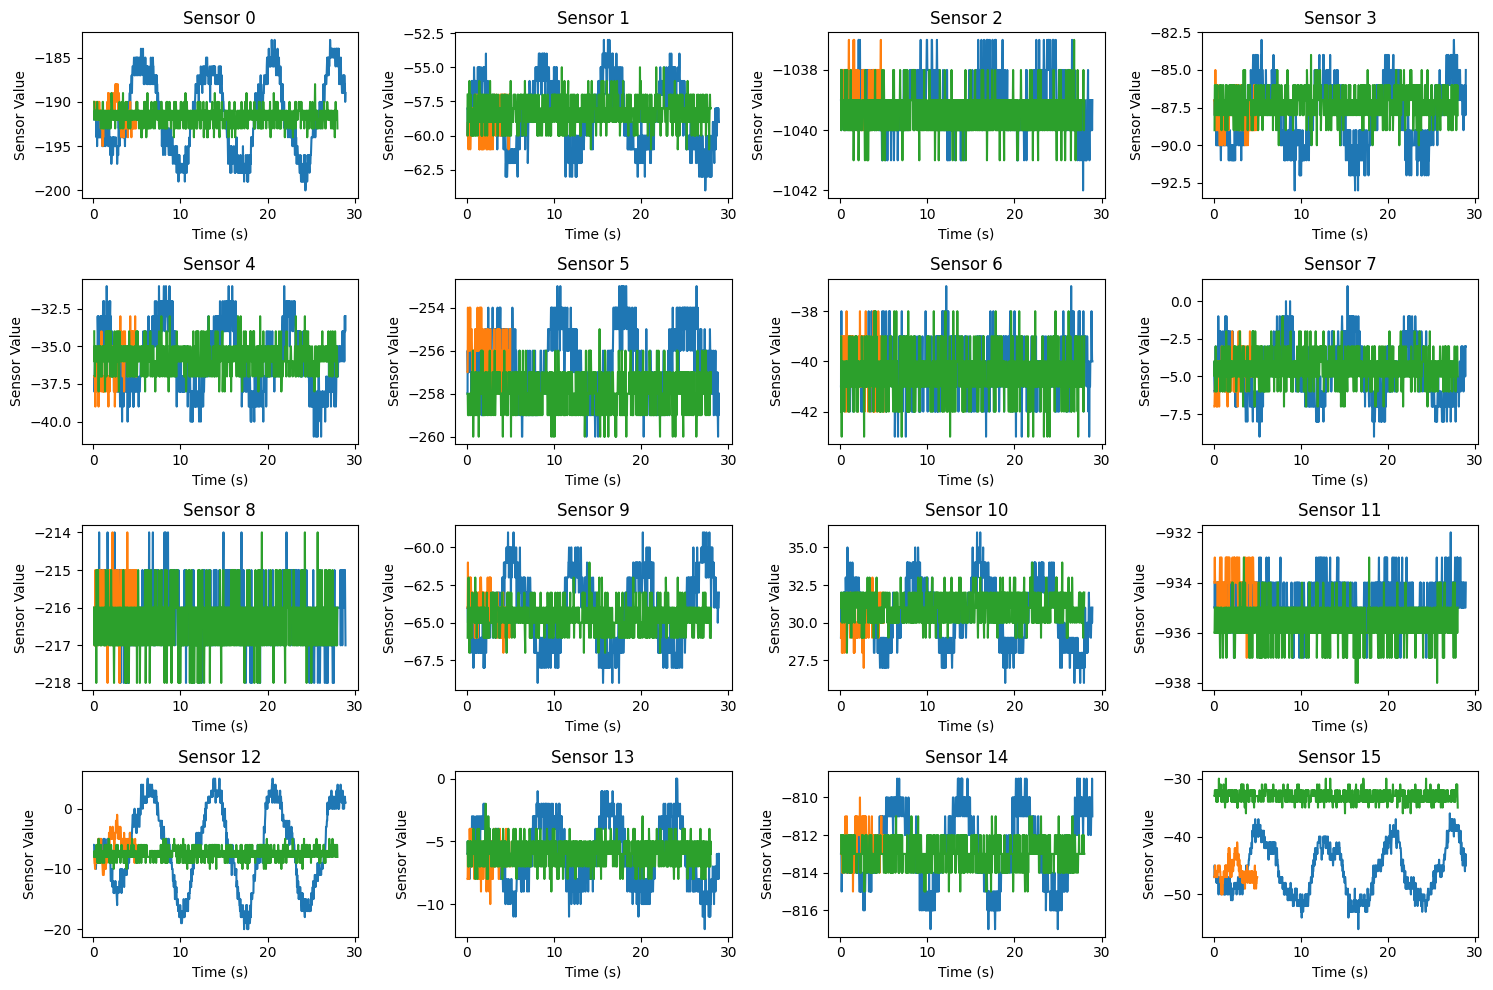

In [37]:
# data_path = "G:\\datasets\\tac2Slip\\severity-03-15"
data_path = "D:\\datasets\\tac2Slip\\severity-03-15"
classes = ['salt-no-slip', 'salt', 'non-contact']
import os
import csv
import time
import numpy as np
def import_csv(file_path):
    with open(file_path, 'r') as f:
        reader = csv.reader(f)
        #skip header
        next(reader)
        data = []
        for row in reader:
            data.append([float(i) for i in row])
    data = np.array(data, dtype=np.float32)
    time = data[:, 0]
    data = data[:, 1:]
    return time, data

c = 1
i = 0
file_path = os.path.join(data_path, classes[1], f"tactile_data{i:04d}.csv")
time_slip, data_slip = import_csv(file_path)

print(f"{data_slip.shape=}")
print(f"{time_slip.shape=}")

file_path = os.path.join(data_path, classes[0], f"tactile_data{i:04d}.csv")
time_no_slip, data_no_slip = import_csv(file_path)
print(f"{data_no_slip.shape=}")
print(f"{time_no_slip.shape=}")

file_path = os.path.join(data_path, classes[2], f"tactile_data{i:04d}.csv")
time_non_contact, data_non_contact = import_csv(file_path)
print(f"{data_non_contact.shape=}")
print(f"{time_non_contact.shape=}")

# --------------------------- Plot first 16 channels across time -------------------------- #
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4, figsize=(15, 10))
for j in range(16):
    ax = axs[j // 4, j % 4]
    ax.plot(time_slip, data_slip[:, j])
    ax.plot(time_no_slip, data_no_slip[:, j])
    ax.plot(time_non_contact, data_non_contact[:, j])
    ax.set_title(f'Sensor {j}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Sensor Value')
plt.tight_layout()
plt.show()

In [44]:
# import lstm_model.pth

import torch
import sys
sys.path.append(r"D:\\UNI\\Studentermedhjaelper\\slip_severity")
sys.path.append(r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity")
from src.LSTM import LSTMModel
import sys


model = LSTMModel(input_dim=51, hidden_dim=128, layers=2, output_dim=3)
# model.load_state_dict(torch.load(r"D:\\UNI\\Studentermedhjaelper\\slip_severity\\lstm_model.pth"))
model.load_state_dict(torch.load(r"C:\\Users\\Caspe\\Documents\\Studentermedhjælper\\slip_severity\\lstm_model.pth", map_location=torch.device('cpu')))
model.eval()
print(f"{data_slip.shape=}")
X = torch.from_numpy(data_slip).unsqueeze(0)[:,:, :51]  # shape (1, seq_len, 51)
Y_pose = torch.from_numpy(data_slip).unsqueeze(0)[:,:, 255:255+3]  # shape (1, seq_len, 3)
# take first order difference of Y to get the change in slip severity
dt = torch.from_numpy(np.diff(time_slip).astype(np.float32)).view(1, -1, 1)
Y = torch.diff(Y_pose, dim=1) / dt
time_slip_trimmed = time_slip[1:]
X = X[:, 1:, :]  # remove the first time step to match the shape of Y
print(f"{X.shape=}, {Y.shape=}")

pred = []
with torch.no_grad():
    for i in range(X.shape[1]):
        if i < 20:
            x_i = X[:, :i+1, :] 
        else:
            x_i = X[:, i-20:i+1, :]  # shape (1, 21, 51)
        # print(f"{x_i.shape=}")

        pred_i = model(x_i/1024)
        # print(f"{pred_i=}")
        pred.append(pred_i)

pred = torch.stack(pred, dim=1)  # shape (1, seq_len, 3)
print(f"{pred.shape=}")



data_slip.shape=(869, 290)
X.shape=torch.Size([1, 868, 51]), Y.shape=torch.Size([1, 868, 3])
pred.shape=torch.Size([1, 868, 3])


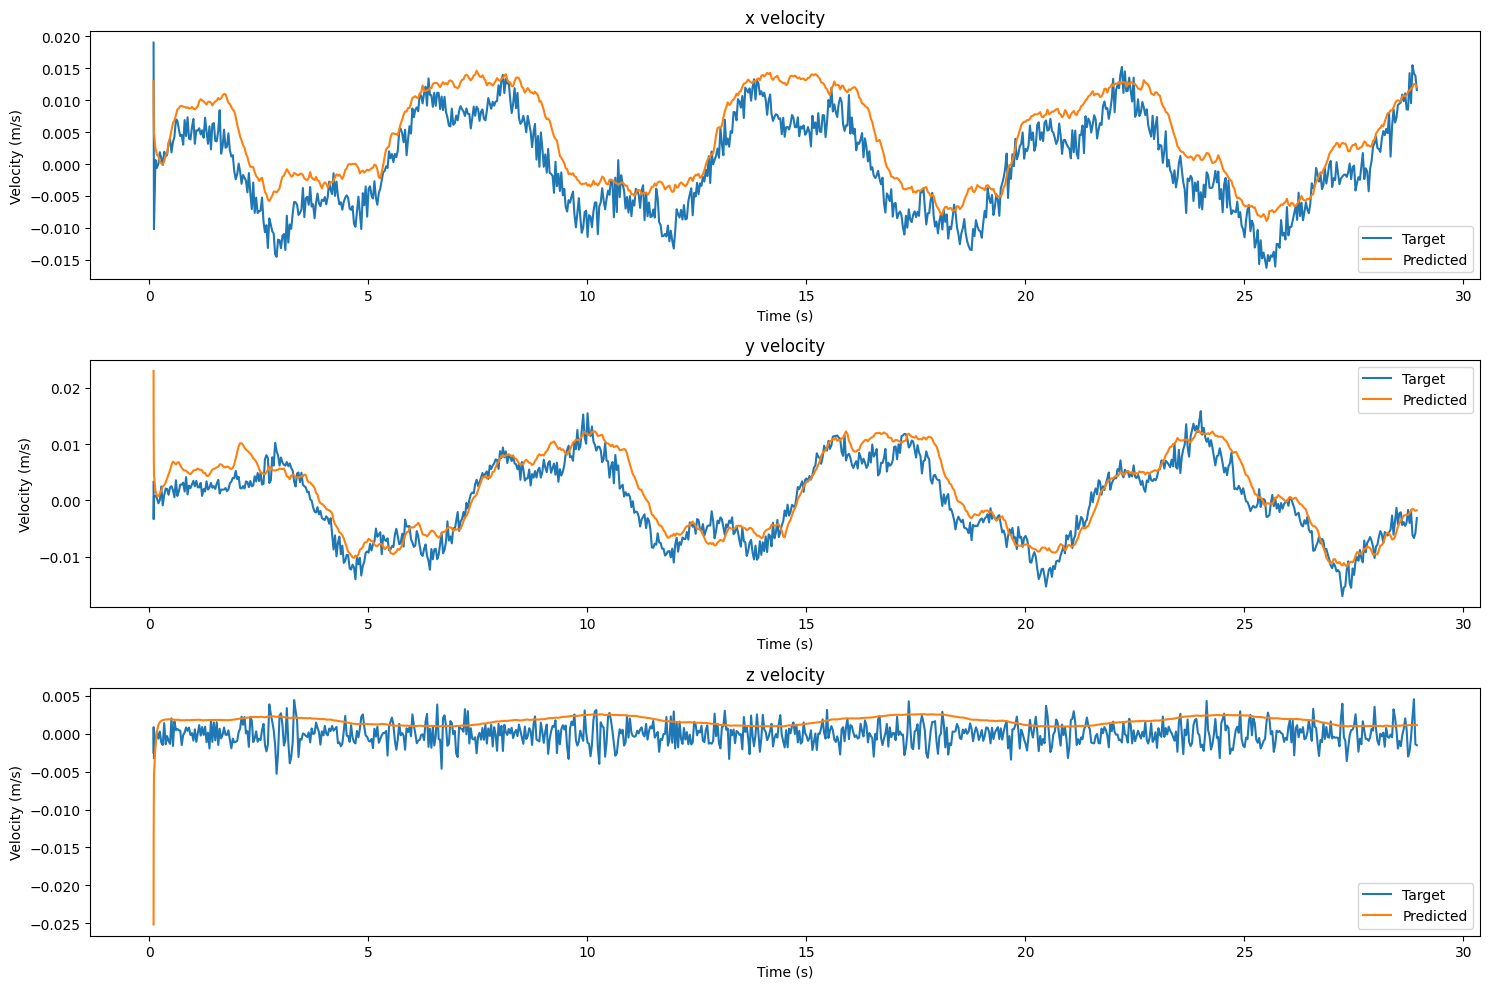

In [47]:
# plot predictions vs targets for each class across time
fig, axs = plt.subplots(3, 1, figsize=(15, 10))

class_LUT = {0: "x", 1: "y", 2: "z"}
for j in range(3):
    ax = axs[j]
    ax.plot(time_slip_trimmed, Y[0, :, j].numpy(), label='Target')
    ax.plot(time_slip_trimmed, pred[0, :, j].numpy(), label='Predicted')
    ax.set_title(f'{class_LUT[j]} velocity')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
plt.tight_layout()
plt.show()